# Анализ факторов, влияющих на медицинские страховые выплаты

- Автор: Зотова Дарья
- Дата: 16.01.2026

### Краткое описание проекта

Проект посвящён изучению влияния пола, региона проживания и BMI на страховые выплаты. Датасет содержит 1338 записей о застрахованных лицах с информацией о возрасте, поле, BMI, числе детей, курении, регионе и размере страховых выплат. Для выявления значимых зависимостей используются статистический анализ и визуализация данных.

### Цель и задачи проекта

**Цель:** 

Исследовать влияние пола, региона и BMI на размер страховых выплат, выявить статистически значимые зависимости и оценить их практическую ценность для страховой компании.

**Задачи:**
1. Провести предобработку и очистку данных для корректного анализа.
2. Провести исследовательский анализ и изучить структуру данных.
3. Проверить гипотезы с помощью статистических методов:
   - пол влияет на размер страховых выплат,
   - регион проживания влияет на размер страховых выплат,
   - более высокий BMI связан с более высокими страховыми выплатами.
4. Сделать выводы о статистической значимости выявленных зависимостей.
5. Сформулировать практические рекомендации для страховой компании.

### Описание данных

В проекте использовался датасет [US Health Insurance Dataset](https://www.kaggle.com/datasets/teertha/ushealthinsurancedataset/data) с платформы Kaggle.

**Описание датасета:**
- `age` — возраст застрахованного,
- `sex` — пол застрахованного,
- `bmi` — индекс массы тела застрахованного,
- `children` — количество детей,
- `smoker` — статус курения (yes/no),
- `region` — регион проживания,
- `charges` — сумма медицинских расходов, оплаченных страховой компанией.

Каждая строка датасета представляет собой информацию о конкретном застрахованном и его медицинских расходах, оплаченных страховой компанией. Датасет не содержит пропусков.

### Содержимое проекта

1. Загрузка данных и знакомство с ними
2. Предобработка данных
    - 2.1. Типы данных
    - 2.2. Дубликаты в данных
3. Исследовательский анализ данных:
    - 3.1. Анализ категориальных данных
    - 3.2. Анализ числовых данных
    - 3.3. Промежуточные выводы по исследовательскому анализу
4. Проверка гипотез:
    - 4.1. Гипотеза 1. Пол влияет на размер страховых выплат
    - 4.2. Гипотеза 2. Регион проживания влияет на размер страховых выплат
    - 4.3. Более высокий BMI связан с более высокими страховыми выплатами
5. Итоговый вывод и рекомендации
    - 5.1. Общий обзор проделанной работы
    - 5.2. Главные выводы
    - 5.3. Рекомендации

---

## Загрузка данных и знакомство с ними

In [1]:
# Импортируем библиотеки
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as st
import statsmodels.stats.oneway as smw
from scipy.stats import levene
from scipy.stats import mannwhitneyu
from scipy.stats import kruskal
from scipy.stats import spearmanr

In [2]:
# Выгружаем данные
insurance_df = pd.read_csv('C:/Users/Админ/Desktop/pet projects/health/insurance.csv')

Познакомимся с данными датасета — выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [3]:
# Выводим первые строки датафрейма на экран
insurance_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
# Выводим информацию о датафрейме
insurance_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


Датасет содержит 7 столбцов и 1338 строк, в которых представлена информация о застрахованных лицах и соответствующих им медицинских расходах, оплаченных страховой компанией.

После первичного анализа данных можно сделать следующие выводы:

- Названия столбцов соответствуют их содержимому.
- Значения в столбцах представлены корректными типами. Разрядность числовых столбцов можно оптимизировать для экономии памяти.
- На первый взгляд в столбцах не содержится пропусков.
- Значения в столбцах соответствуют своему описанию.

---

## Предобработка данных

### Типы данных

Оптимизируем разрядность числовых столбцов для экономии памяти.

In [5]:
# Оптимизируем разрядность 
int_cols = insurance_df.select_dtypes(include='int').columns
float_cols = insurance_df.select_dtypes(include='float').columns

insurance_df[int_cols] = insurance_df[int_cols].apply(pd.to_numeric, downcast='integer')
insurance_df[float_cols] = insurance_df[float_cols].apply(pd.to_numeric, downcast='float')

In [6]:
# Проверяем преобразования
insurance_df.dtypes

age            int8
sex          object
bmi         float32
children       int8
smoker       object
region       object
charges     float64
dtype: object


---

### Дубликаты в данных

Перед проверкой на дубликаты нормализуем данные в текстовых столбцах.

In [7]:
# Нормализуем данные
object_cols = insurance_df.select_dtypes(include='object').columns
for col in object_cols:
    insurance_df[col] = insurance_df[col].str.lower().str.strip()

Проверим, есть ли в данных полные дубликаты.

In [8]:
# Проверяем полные дубликаты
insurance_df.duplicated().sum()

np.int64(1)

Одна строка полностью совпадает с другой по всем столбцам. Оставим её в данных, так как она практически не влияет на результаты и может представлять другого застрахованного.

---

## Исследовательский анализ данных

### Анализ категориальных данных

Посмотрим на распределение застрахованных по категориальным признакам.

In [9]:
# Проверяем распределение в абсолютных значениях
insurance_df['sex'].value_counts().sort_values(ascending=False)

sex
male      676
female    662
Name: count, dtype: int64

In [10]:
# Проверяем распределение в относительных значениях
insurance_df['sex'].value_counts(normalize=True).sort_values(ascending=False)

sex
male      0.505232
female    0.494768
Name: proportion, dtype: float64

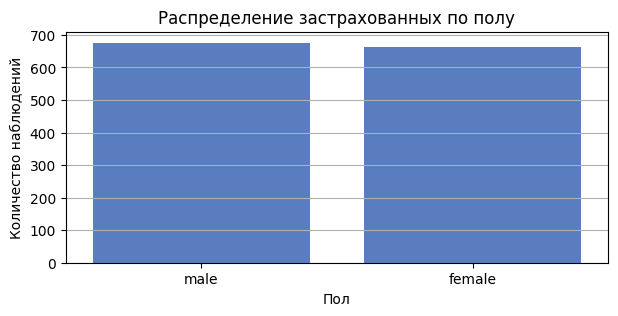

In [11]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Настраиваем палитру
palette = sns.color_palette('muted')

# Строим столбчатую диаграмму
sns.barplot(data=insurance_df['sex'].value_counts().sort_values(ascending=False).reset_index(),
            x='sex',
            y='count',
            color=palette[0])

# Настраиваем подписи
plt.title('Распределение застрахованных по полу')
plt.xlabel('Пол')
plt.ylabel('Количество наблюдений')

# Добавляем сетку графика
plt.grid(axis="y")

# Выводим график
plt.show()

В датасете примерно одинаковое число мужчин и женщин — 676 (50,5%) и 662 (49,5%) человека соответственно.

In [12]:
# Проверяем распределение в абсолютных значениях
insurance_df['children'].value_counts().sort_values(ascending=False)

children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

In [13]:
# Проверяем распределение в относительных значениях
insurance_df['children'].value_counts(normalize=True).sort_values(ascending=False)

children
0    0.428999
1    0.242152
2    0.179372
3    0.117339
4    0.018685
5    0.013453
Name: proportion, dtype: float64

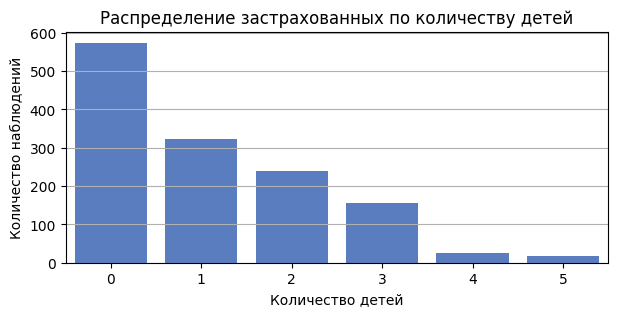

In [14]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Настраиваем палитру
palette = sns.color_palette('muted')

# Строим столбчатую диаграмму
sns.barplot(data=insurance_df['children'].value_counts().sort_values(ascending=False).reset_index(),
            x='children',
            y='count',
            color=palette[0])

# Настраиваем подписи
plt.title('Распределение застрахованных по количеству детей')
plt.xlabel('Количество детей')
plt.ylabel('Количество наблюдений')

# Добавляем сетку графика
plt.grid(axis="y")

# Выводим график
plt.show()

Большинство застрахованных не имеют детей (574 человека, 43%) или имеют одного ребёнка (324 человека, 24%). Число застрахованных уменьшается с ростом количества детей: два ребёнка у 240 (18%), три — у 157 (11,7%). С четырьмя или пятью детьми 43 человека вместе (3,3%). Таким образом, семьи с большим числом иждивенцев в датасете встречаются редко.

In [15]:
# Проверяем распределение в абсолютных значениях
insurance_df['smoker'].value_counts().sort_values(ascending=False)

smoker
no     1064
yes     274
Name: count, dtype: int64

In [16]:
# Проверяем распределение в относительных значениях
insurance_df['smoker'].value_counts(normalize=True).sort_values(ascending=False)

smoker
no     0.795217
yes    0.204783
Name: proportion, dtype: float64

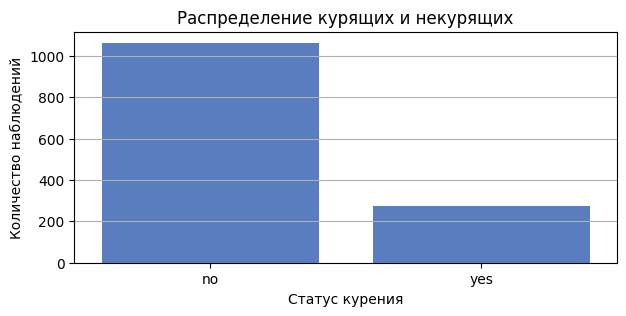

In [17]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Настраиваем палитру
palette = sns.color_palette('muted')

# Строим столбчатую диаграмму
sns.barplot(data=insurance_df['smoker'].value_counts().sort_values(ascending=False).reset_index(),
            x='smoker',
            y='count',
            color=palette[0])

# Настраиваем подписи
plt.title('Распределение курящих и некурящих')
plt.xlabel('Статус курения')
plt.ylabel('Количество наблюдений')

# Добавляем сетку графика
plt.grid(axis="y")

# Выводим график
plt.show()

Большинство застрахованных не курят — 1064 человека (80%) против 274 курящих (20%). Группы несбалансированы, поэтому при сравнении страховых выплат стоит учитывать разный размер и разброс данных, а при необходимости использовать устойчивые к неравенству дисперсий тесты, например `t-test Уэлча`.

In [18]:
# Проверяем распределение в абсолютных значениях
insurance_df['region'].value_counts().sort_values(ascending=False)

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [19]:
# Проверяем распределение в относительных значениях
insurance_df['region'].value_counts(normalize=True).sort_values(ascending=False)

region
southeast    0.272048
southwest    0.242900
northwest    0.242900
northeast    0.242152
Name: proportion, dtype: float64

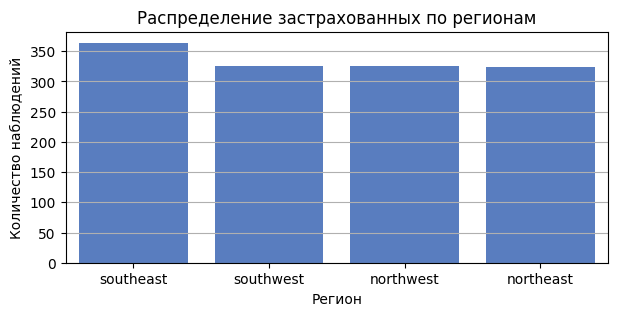

In [20]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Настраиваем палитру
palette = sns.color_palette('muted')

# Строим столбчатую диаграмму
sns.barplot(data=insurance_df['region'].value_counts().sort_values(ascending=False).reset_index(),
            x='region',
            y='count',
            color=palette[0])

# Настраиваем подписи
plt.title('Распределение застрахованных по регионам')
plt.xlabel('Регион')
plt.ylabel('Количество наблюдений')

# Добавляем сетку графика
plt.grid(axis="y")

# Выводим график
plt.show()

Распределение застрахованных по регионам практически равномерное. Численно немного больше людей проживает в Southeast (364 человека, около 27%), тогда как в остальных трёх регионах — примерно по 325 человек (около 24%). Различия между регионами минимальны, что удобно для последующего анализа и сравнения страховых выплат по регионам.

---

### Анализ числовых данных

In [21]:
# Изучаем статистические показатели 
insurance_df['age'].describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

Средний возраст застрахованных составляет около 39 лет, половина находится в диапазоне от 27 до 51 года. Возраст варьируется от 18 до 64 лет, без явных выбросов. Стандартное отклонение около 14 лет указывает на умеренное разброс возрастов среди застрахованных.

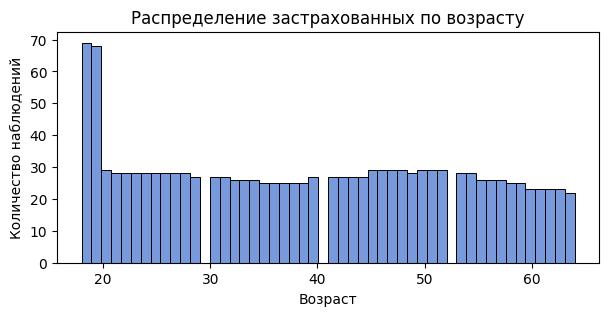

In [22]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Настраиваем палитру
palette = sns.color_palette('muted')

# Строим график распределения
sns.histplot(data=insurance_df, x='age', bins=50, color=palette[0])

# Настраиваем подписи
plt.title('Распределение застрахованных по возрасту')
plt.xlabel('Возраст')
plt.ylabel('Количество наблюдений')

# Выводим график
plt.show()

Судя по графику, можно сделать следующие выводы:

1. Пик в молодом возрасте: Наибольшее количество застрахованных — около 18–20 лет. Это явный всплеск, заметно выше, чем у остальных возрастных групп.
2. Стабильное количество у взрослых: После 20 лет количество застрахованных стабильно, колеблется примерно от 22 до 30 человек на возрастную группу.
3. Постепенное снижение в старших возрастах: После 50–55 лет наблюдается небольшое снижение числа застрахованных, к 60–64 годам оно падает до 22 человек.

Главное: большинство застрахованных — молодые люди (особенно около 18–20 лет), а дальше распределение более равномерное с лёгким спадом к старшим возрастам.

In [23]:
# Изучаем статистические показатели 
insurance_df['bmi'].describe()

count    1338.000000
mean       30.663397
std         6.098187
min        15.960000
25%        26.296251
50%        30.400000
75%        34.693750
max        53.130001
Name: bmi, dtype: float64

Средний индекс массы тела застрахованных составляет около 30,6, а медиана — 30,4, распределение примерно симметрично. Половина людей имеет BMI между 26,3 и 34,7. Значения варьируются от 15,96 до 53,13, при этом отдельные высокие значения можно рассматривать как потенциальные выбросы, которые стоит учитывать при анализе страховых выплат.

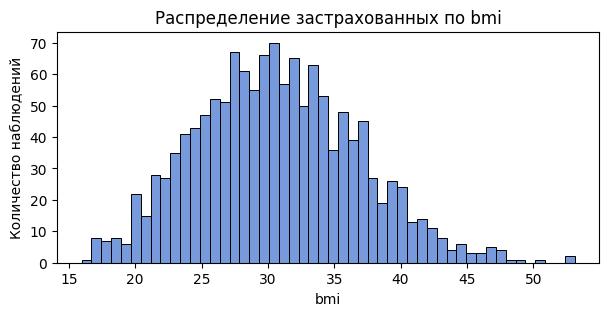

In [24]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Настраиваем палитру
palette = sns.color_palette('muted')

# Строим график распределения
sns.histplot(data=insurance_df, x='bmi', bins=50, color=palette[0])

# Настраиваем подписи
plt.title('Распределение застрахованных по bmi')
plt.xlabel('bmi')
plt.ylabel('Количество наблюдений')

# Выводим график
plt.show()

Распределение выглядит примерно нормальным с небольшой асимметрией вправо. Это означает, что есть несколько людей с очень высоким BMI — потенциальные выбросы. Наибольшее количество застрахованных находится примерно в диапазоне 28–32 bmi. То есть большинство людей в датасете имеют избыточный вес по стандартной классификации bmi.

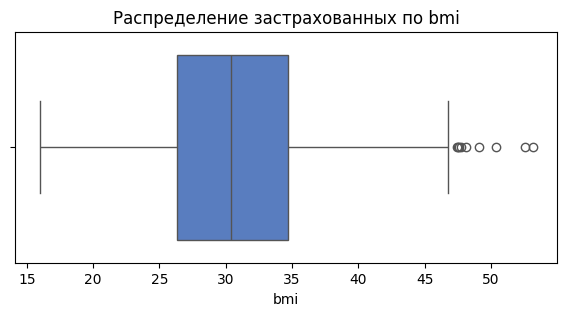

In [25]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Настраиваем палитру
palette = sns.color_palette('muted')

# Строим диаграмму размаха
sns.boxplot(data=insurance_df, x='bmi', color=palette[0])

# Настраиваем подписи
plt.title('Распределение застрахованных по bmi')
plt.xlabel('bmi')

# Выводим график
plt.show()

График подтверждает, что выбросы есть (bmi от 47), но они редки и сильно не смещают среднее, поэтому для большинства тестов их можно оставить, просто учитывая при интерпретации.

In [26]:
# Изучаем статистические показатели 
insurance_df['charges'].describe()

count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64

Средние страховые выплаты составляют около 13 270, а медиана — 9 382, что указывает на скошенность распределения вправо. Половина застрахованных имеет расходы между 4 740 и 16 640. Максимальные значения достигают 63 770, что говорит о наличии редких, но очень высоких выплат, которые следует учитывать при проверке гипотез.

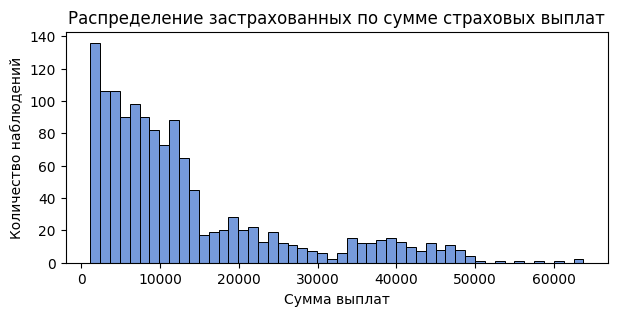

In [27]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Настраиваем палитру
palette = sns.color_palette('muted')

# Строим график распределения
sns.histplot(data=insurance_df, x='charges', bins=50, color=palette[0])

# Настраиваем подписи
plt.title('Распределение застрахованных по сумме страховых выплат')
plt.xlabel('Сумма выплат')
plt.ylabel('Количество наблюдений')

# Выводим график
plt.show()

График подтверждает, что распределение сильно скошено вправо: большинство застрахованных получает небольшие суммы выплат, основная масса — примерно до 10–15 тыс. Есть длинный правый хвост — небольшая доля случаев с очень крупными выплатами (до ~60+ тыс.).

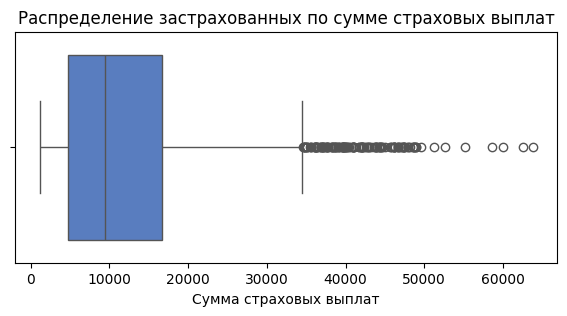

In [28]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Настраиваем палитру
palette = sns.color_palette('muted')

# Строим диаграмму размаха
sns.boxplot(data=insurance_df, x='charges', color=palette[0])

# Настраиваем подписи
plt.title('Распределение застрахованных по сумме страховых выплат')
plt.xlabel('Сумма страховых выплат')

# Выводим график
plt.show()

Boxplot показывает много выбросов по верхней границе: крупные выплаты редки, но существенно влияют на общую картину. Верхняя граница выплат без выбросов достигает 35 тыс.

### Промежуточные выводы по исследовательскому анализу

По результатам исследовательского анализа можно сделать следующие выводы:

**1. Структура данных**

- В выборке 1338 застрахованных, распределение по полу почти равномерное: мужчины — 50,5%, женщины — 49,5%.
- Большинство застрахованных не имеют детей (43%) или имеют одного ребёнка (24%), семьи с четырьмя и более детьми редки (3,3%).
- Курящие составляют 20% выборки, некурящие — 80%, группы несбалансированы.
- Распределение по регионам приблизительно равномерное (24–27% на регион).

**2. Числовые признаки**

- Средний возраст — около 39 лет, 50% значений лежат в диапазоне 27–51 года, выбросов не выявлено.
- BMI имеет среднее 30,6 и медиану 30,4, распределение близко к симметричному, редкие высокие значения (более 47) не искажают общую картину.
- Страховые выплаты имеют сильную асимметрию вправо: медиана (9 382) заметно ниже среднего (13 270), присутствуют редкие, но очень высокие значения (до 63 770).

**3. Влияние на проверку гипотез**

- Из-за скошенности и выбросов в `charges` предпочтительны устойчивые тесты (`t-test Уэлча`, непараметрические аналоги).
- Равномерность регионов и отсутствие проблем с BMI позволяют использовать ANOVA и корреляционный анализ с учётом предпосылок.

---

## Проверка гипотез

В датасете отсутствует уникальный идентификатор застрахованного, поэтому формально невозможно проверить, представлены ли в данных повторные наблюдения одного и того же человека. Однако исходя из описания датасета и структуры данных, каждая строка интерпретируется как отдельный застрахованный. Поэтому в рамках анализа предпосылку о независимости наблюдений будем считать выполненной для всех тестов.

### Гипотеза 1. Пол влияет на размер страховых выплат

**Формулировка гипотез**

- H0: Средние страховые выплаты у мужчин и женщин не отличаются.
- H1: Средние страховые выплаты у мужчин и женщин отличаются.

**Проверка предпосылок**

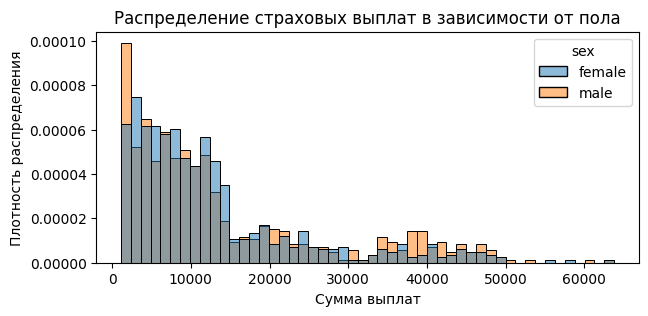

In [29]:
# Создаём контейнер графика
plt.figure(figsize=(7, 3))

# Настраиваем палитру
palette = sns.color_palette('muted')

# Строим график распределения
sns.histplot(data=insurance_df,
             x='charges',
             bins=50,
             color=palette[0], 
             hue='sex',
             stat='density',
             common_norm=False)

# Настраиваем подписи
plt.title('Распределение страховых выплат в зависимости от пола')
plt.xlabel('Сумма выплат')
plt.ylabel('Плотность распределения')

# Выводим график
plt.show()

Проведём тест Левена для проверки гипотезы о равенстве дисперсий.

- H0: дисперсии в группах равны.
- H1: дисперсии в группах отличаются.

In [30]:
alpha = 0.05

# Разбиваем данные по регионам
groups = [
    insurance_df.loc[insurance_df['sex'] == sex, 'charges']
    for sex in insurance_df['sex'].unique()
]

# Тест Левена
stat, p_value = levene(*groups)

if p_value > alpha:
    print(f'Полученное значение p_value={p_value} больше критического уровня alpha={alpha}.')
    print('Не получилось отвергнуть нулевую гипотезу.')
else:
    print(f'Полученное значение p_value={p_value} меньше критического уровня alpha={alpha}.') 
    print('Отвергаем нулевую гипотезу.')

Полученное значение p_value=0.0016808765833903443 меньше критического уровня alpha=0.05.
Отвергаем нулевую гипотезу.


Выводы по предпосылкам:

1. Несмотря на отклонение распределений страховых выплат от нормального, объёмы выборок в группах мужчин и женщин достаточно велики (676 и 662 соответственно). В силу ЦПТ распределения выборочных средних можно считать приближённо нормальными, что позволяет применять параметрические методы для сравнения средних страховых выплат.

2. Распределения у мужчин и женщин похожи: в основном небольшие выплаты и редкие крупные, без заметных различий в характере выплат.

3. Тест Левена показал статистически значимые различия дисперсий между полами (p-value = 0.0017 < 0.05). Следовательно, предпосылка равенства дисперсий нарушена.

**Выбор и проведение теста**

Поскольку исследуемая гипотеза касается различий средних страховых выплат между мужчинами и женщинами, а дисперсии в группах неодинаковы (по тесту Левена), для проверки имеет смысл использовать `t-тест Уэлча`, устойчивый к нарушению предпосылки гомогенности дисперсий. Несмотря на ненормальность распределений страховых выплат, достаточно большие объёмы выборок (676 и 662) позволяют применять параметрические методы анализа в соответствии с центральной предельной теоремой.

In [31]:
alpha = 0.05

male_mean = insurance_df[insurance_df['sex'] == 'male']['charges'].mean()
female_mean = insurance_df[insurance_df['sex'] == 'female']['charges'].mean()

print(f'Средние страховые выплаты мужчин: {round(male_mean)}')
print(f'Средние страховые выплаты женщин: {round(female_mean)}')
print('')

# t-тест Уэлча
stat, p_value = st.ttest_ind(
    insurance_df.loc[insurance_df['sex'] == 'male', 'charges'],
    insurance_df.loc[insurance_df['sex'] == 'female', 'charges'],
    equal_var=False,
    alternative='two-sided')

if p_value > alpha:
    print(f'Полученное значение p_value={p_value} больше критического уровня alpha={alpha}.')
    print('Не получилось отвергнуть нулевую гипотезу.')
else:
    print(f'Полученное значение p_value={p_value} меньше критического уровня alpha={alpha}.') 
    print('Отвергаем нулевую гипотезу.')

Средние страховые выплаты мужчин: 13957
Средние страховые выплаты женщин: 12570

Полученное значение p_value=0.03584101495601664 меньше критического уровня alpha=0.05.
Отвергаем нулевую гипотезу.


Для проверки устойчивости вывода дополнительно проведём тест `Манна–Уитни`, что допустимо из-за схожести форм распределений страховых выплат у мужчин и женщин.

In [32]:
alpha = 0.05

# Тест Манна–Уитни
stat, p_value = mannwhitneyu(
    insurance_df.loc[insurance_df['sex'] == 'male', 'charges'],
    insurance_df.loc[insurance_df['sex'] == 'female', 'charges'],
    alternative='two-sided'
)

if p_value > alpha:
    print(f'Полученное значение p_value={p_value} больше критического уровня alpha={alpha}.')
    print('Не получилось отвергнуть нулевую гипотезу.')
else:
    print(f'Полученное значение p_value={p_value} меньше критического уровня alpha={alpha}.') 
    print('Отвергаем нулевую гипотезу.')

Полученное значение p_value=0.7286510894470093 больше критического уровня alpha=0.05.
Не получилось отвергнуть нулевую гипотезу.


**Интерпретация результатов**

Средние страховые выплаты у мужчин статистически значимо выше, чем у женщин (t-тест Уэлча, p_value = 0.036 < 0.05). При этом тест Манна–Уитни не выявил различий в распределениях выплат, что указывает на то, что различие средних обусловлено редкими, но очень крупными выплатами у мужчин, а не систематически более высокими выплатами в целом.

Проще говоря, у мужчин и женщин типичные страховые выплаты сопоставимы, однако мужчины несколько чаще попадают в ситуации с экстремально высокими затратами.

Для страховой компании это означает, что пол сам по себе слабо влияет на типичный уровень риска, но может быть важен при оценке вероятности крупных убытков. Поэтому пол не стоит использовать для повышения базового тарифа, но он может быть полезен при оценке риска крупных убытков и формировании финансовых резервов..

---

### Гипотеза 2. Регион проживания влияет на размер страховых выплат

**Формулировка гипотез**

- H0: Средние страховые выплаты одинаковы во всех регионах.
- H1: Хотя бы в одном регионе средние страховые выплаты отличаются.

**Проверка предпосылок**

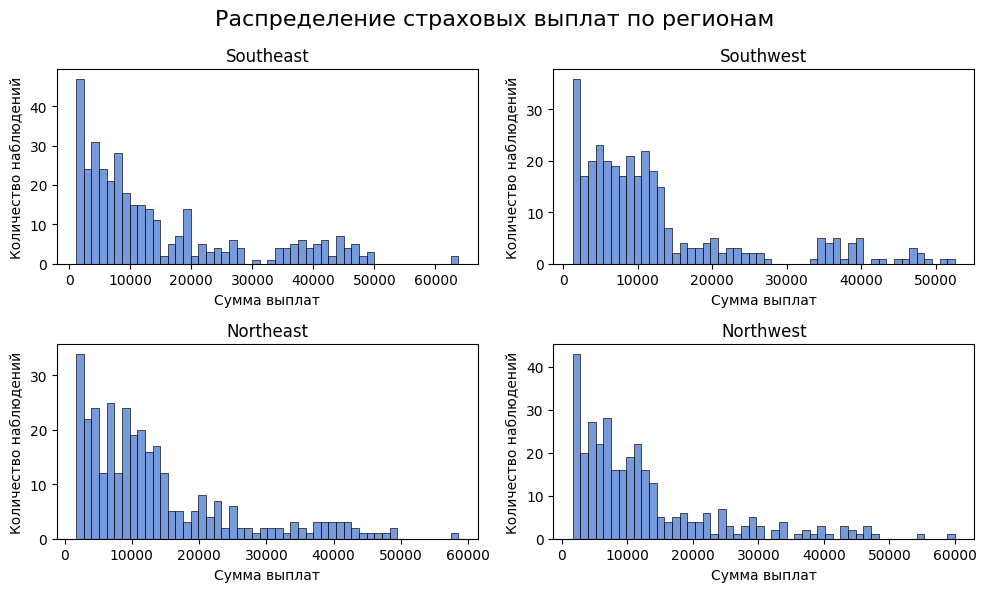

In [33]:
# Создаём контейнер графика (2 х 2) и задаём его размер
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

# Настраиваем палитру
palette = sns.color_palette('muted')

# Общий заголовок для всей фигуры
fig.suptitle('Распределение страховых выплат по регионам', fontsize=16)

# График Southeast
sns.histplot(data=insurance_df[insurance_df['region'] == 'southeast'],
             x='charges',
             bins=50,
             color=palette[0],
             ax = axes[0, 0])
axes[0, 0].set_title('Southeast', fontsize=12)
axes[0, 0].set_xlabel('Сумма выплат')
axes[0, 0].set_ylabel('Количество наблюдений')


# График Southwest
sns.histplot(data=insurance_df[insurance_df['region'] == 'southwest'],
             x='charges',
             bins=50,
             color=palette[0],
             ax = axes[0, 1])
axes[0, 1].set_title('Southwest', fontsize=12)
axes[0, 1].set_xlabel('Сумма выплат')
axes[0, 1].set_ylabel('Количество наблюдений')


# График Northeast
sns.histplot(data=insurance_df[insurance_df['region'] == 'northeast'],
             x='charges',
             bins=50,
             color=palette[0],
             ax = axes[1, 0])
axes[1, 0].set_title('Northeast', fontsize=12)
axes[1, 0].set_xlabel('Сумма выплат')
axes[1, 0].set_ylabel('Количество наблюдений')


# График Northwest
sns.histplot(data=insurance_df[insurance_df['region'] == 'northwest'],
             x='charges',
             bins=50,
             color=palette[0],
             ax = axes[1, 1])
axes[1, 1].set_title('Northwest', fontsize=12)
axes[1, 1].set_xlabel('Сумма выплат')
axes[1, 1].set_ylabel('Количество наблюдений')

# Настраиваем отступы
plt.tight_layout()

# Выводим графики
plt.show()

Проведём тест Левена для проверки гипотезы о равенстве дисперсий.

- H0: дисперсии во всех группах равны.
- H1: хотя бы в одной группе дисперсия отличается.

In [34]:
alpha = 0.05

# Разбиваем данные по регионам
groups = [
    insurance_df.loc[insurance_df['region'] == region, 'charges']
    for region in insurance_df['region'].unique()
]

# Тест Левена
stat, p_value = levene(*groups)

if p_value > alpha:
    print(f'Полученное значение p_value={p_value} больше критического уровня alpha={alpha}.')
    print('Не получилось отвергнуть нулевую гипотезу.')
else:
    print(f'Полученное значение p_value={p_value} меньше критического уровня alpha={alpha}.') 
    print('Отвергаем нулевую гипотезу.')

Полученное значение p_value=0.0008610590250786703 меньше критического уровня alpha=0.05.
Отвергаем нулевую гипотезу.


Выводы по предпосылкам:

1. Во всех регионах распределения страховых выплат имеют выраженную правостороннюю асимметрию с длинным хвостом редких крупных выплат (до 50–60 тыс.). Распределения не являются нормальными, что типично для страховых данных. Однако размеры групп достаточно велики, поэтому умеренное отклонение от нормальности не является критичным.

2. Формы распределений во всех регионах в целом схожи: во всех случаях наблюдается концентрация малых выплат и правый хвост крупных значений.

3. Тест Левена показал статистически значимые различия дисперсий между регионами (p-value = 0.00086 < 0.05). Следовательно, предпосылка равенства дисперсий нарушена.

**Выбор и проведение теста**

Поскольку распределения страховых выплат отклоняются от нормального, но размеры групп велики, а формы распределений в целом сопоставимы, параметрический подход остаётся допустимым. Однако из-за нарушения предпосылки гомогенности дисперсий применение классического однофакторного ANOVA нежелательно. Для проверки гипотезы о различии средних страховых выплат между регионами будем использовать `ANOVA Уэлча`, так как он устойчив к неравенству дисперсий и позволяет корректно сравнивать средние значения.

In [35]:
alpha = 0.05

southeast_mean = insurance_df[insurance_df['region'] == 'southeast']['charges'].mean()
southwest_mean = insurance_df[insurance_df['region'] == 'southwest']['charges'].mean()
northeast_mean = insurance_df[insurance_df['region'] == 'northeast']['charges'].mean()
northwest_mean = insurance_df[insurance_df['region'] == 'northwest']['charges'].mean()

print(f'Средние страховые выплаты в регионе southeast: {round(southeast_mean)}')
print(f'Средние страховые выплаты в регионе southwest: {round(southwest_mean)}')
print(f'Средние страховые выплаты в регионе northeast: {round(northeast_mean)}')
print(f'Средние страховые выплаты в регионе northwest: {round(northwest_mean)}')
print('')

# Разбиваем данные по регионам
groups = [
    insurance_df.loc[insurance_df['region'] == region, 'charges']
    for region in insurance_df['region'].unique()
]

# Тест ANOVA Уэлча
stat, p_value = smw.anova_oneway(groups, use_var='unequal')

if p_value > alpha:
    print(f'Полученное значение p_value={p_value} больше критического уровня alpha={alpha}.')
    print('Не получилось отвергнуть нулевую гипотезу.')
else:
    print(f'Полученное значение p_value={p_value} меньше критического уровня alpha={alpha}.') 
    print('Отвергаем нулевую гипотезу.')

Средние страховые выплаты в регионе southeast: 14735
Средние страховые выплаты в регионе southwest: 12347
Средние страховые выплаты в регионе northeast: 13406
Средние страховые выплаты в регионе northwest: 12418

Полученное значение p_value=0.0505927632193392 больше критического уровня alpha=0.05.
Не получилось отвергнуть нулевую гипотезу.


Поскольку `ANOVA Уэлча` показал пограничный результат (p_value=0.051), дополнительно проведём непараметрический тест `Краскела–Уоллиса` для проверки устойчивости вывода.

In [36]:
alpha = 0.05

# Разбиваем данные по регионам
groups = [
    insurance_df.loc[insurance_df['region'] == region, 'charges']
    for region in insurance_df['region'].unique()
]

# Тест Краскела–Уоллиса
stat, p_value = kruskal(*groups)

if p_value > alpha:
    print(f'Полученное значение p_value={p_value} больше критического уровня alpha={alpha}.')
    print('Не получилось отвергнуть нулевую гипотезу.')
else:
    print(f'Полученное значение p_value={p_value} меньше критического уровня alpha={alpha}.') 
    print('Отвергаем нулевую гипотезу.')

Полученное значение p_value=0.19232908072121002 больше критического уровня alpha=0.05.
Не получилось отвергнуть нулевую гипотезу.


**Интерпретация результатов**

Тест `ANOVA Уэлча` дала пограничный результат (p-value = 0.051), однако нулевая гипотеза отвергнута не была. Более устойчивый к нарушениям предпосылок тест `Краскела–Уоллиса` также не выявил статистически значимых различий между регионами (p-value = 0.19). Это указывает на отсутствие убедительных доказательств различий страховых выплат между регионами. Следовательно, регион проживания является слабым фактором риска и его учёт без других признаков вряд ли повысит качество тарифов или моделей оценки риска.

---

### Гипотеза 3. Более высокий BMI связан с более высокими страховыми выплатами

**Формулировка гипотез**

- H0: Между BMI и страховыми выплатами нет значимой связи.
- H1: С ростом BMI страховые выплаты увеличиваются.

**Анализ связи между параметрами**

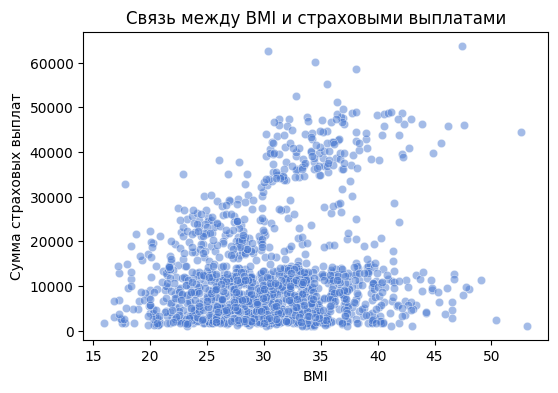

In [37]:
# Создаём контейнер графика
plt.figure(figsize=(6, 4))

# Настраиваем палитру
palette = sns.color_palette('muted')

# Строим диаграмму рассеяния
sns.scatterplot(
    data=insurance_df,
    x='bmi',
    y='charges',
    color=palette[0],
    alpha=0.5
)

# Настраиваем подписи
plt.title('Связь между BMI и страховыми выплатами')
plt.xlabel('BMI')
plt.ylabel('Сумма страховых выплат')

# Выводим график
plt.show()

In [38]:
alpha = 0.05

# Коэффициент Спирмена между BMI и страховыми выплатами
rho, p_value = spearmanr(
    insurance_df['bmi'],
    insurance_df['charges']
)

print(f"Коэффициент Спирмена между BMI и страховыми выплатами: {rho:.3f}")
print('')
if p_value > alpha:
    print(f'Полученное значение p_value={p_value} больше критического уровня alpha={alpha}.')
    print('Cтатистически значимых доказательств связи нет.')
else:
    print(f'Полученное значение p_value={p_value} меньше критического уровня alpha={alpha}.') 
    print('Cвязь статистически значима.')

Коэффициент Спирмена между BMI и страховыми выплатами: 0.119

Полученное значение p_value=1.1926059544526874e-05 меньше критического уровня alpha=0.05.
Cвязь статистически значима.


**Интерпретация результатов**

Визуальный анализ scatter plot показал отсутствие выраженной линейной зависимости между BMI и страховыми выплатами, однако выявил слабую положительную тенденцию: при увеличении BMI чаще встречаются более высокие и более вариативные страховые выплаты. При низких и средних значениях BMI основная масса выплат сосредоточена в нижнем диапазоне, тогда как при BMI выше 30 заметно возрастает разброс и доля крупных выплат, хотя низкие суммы по-прежнему преобладают.

Результат корреляционного анализа подтверждает эти наблюдения: коэффициент Спирмена составил 0.119 (p-value < 0.001), что указывает на слабую, но статистически значимую положительную монотонную связь между BMI и страховыми выплатами. Таким образом, рост BMI связан с повышенным риском крупных страховых расходов, однако сам по себе этот параметр не является определяющим фактором и, вероятно, влияет на выплаты в сочетании с другими характеристиками застрахованных.

---

## Итоговый вывод и рекомендации

### Общий обзор проделанной работы

В проекте исследован датасет из 1338 наблюдений с данными о застрахованных и размере их медицинских расходов, оплаченных страховой компанией. Датасет не содержит пропусков.

Работа включала:
- предобработку данных (оптимизацию разрядности числовых признаков, проверку дубликатов);
- исследовательский анализ данных с изучением распределений, выбросов и структуры признаков;
- проверку гипотез о влиянии пола, региона проживания и BMI на величину страховых выплат с использованием параметрических и непараметрических методов с учётом предпосылок.

---

### Главные выводы

**Структура и свойства данных**

- Выборка сбалансирована по полу (~50/50) и регионам (24–27% на регион).
- Курящие составляют 20%, некурящие — 80%.
- Распределение страховых выплат скошено вправо: медиана — 9 382, среднее — 13 270, максимальные значения доходят до 63 770, что типично для страховых данных.

**Гипотеза 1. Влияние пола на страховые выплаты**

- Средние выплаты: мужчины — 13 957, женщины — 12 570.
- t-тест Уэлча: p-value = 0.036 < 0.05 → различие средних статистически значимо.
- тест Манна–Уитни: p-value = 0.73 > 0.05 → различий в распределениях не выявлено.
- Вывод: Различие средних страховых выплат между мужчинами и женщинами обусловлено редкими, но очень крупными выплатами у мужчин, а не систематически более высокими расходами в целом. Типичный уровень выплат у мужчин и женщин сопоставим.

**Гипотеза 2. Влияние региона проживания**

- Средние выплаты по регионам находятся в диапазоне 12 347 – 14 735.
- ANOVA Уэлча: p-value = 0.051 → погранично, но выше 0.05.
- Краскел–Уоллис: p-value = 0.19 > 0.05 → значимых различий не выявлено.
- Вывод: Статистически значимых различий страховых выплат между регионами не выявлено. Регион проживания сам по себе не является значимым фактором риска.

**Гипотеза 3. Связь BMI и страховых выплат**

- По scatter plot: линейной зависимости нет, но при BMI > 30 чаще встречаются крупные и более вариативные выплаты.
- Коэффициент Спирмена: ρ = 0.119, p-value < 0.001.
- Вывод: BMI имеет слабую, но статистически значимую положительную связь со страховыми выплатами. Рост BMI увеличивает вероятность крупных расходов, но не является определяющим фактором сам по себе.



---

### Рекомендации

1. Не использовать пол и регион как самостоятельные основания для повышения базовых страховых тарифов, поскольку их влияние на типичный уровень страховых выплат ограничено и не затрагивает основную массу клиентов.

2. Учитывать пол и BMI при оценке риска крупных страховых убытков, так как именно в правом хвосте распределения (редкие, но дорогостоящие случаи) у мужчин и у застрахованных с высоким BMI наблюдается повышенная вариативность и более высокие выплаты.

3. Применять многомерные модели оценки риска, в которых пол, BMI, возраст и поведенческие факторы (например, курение) рассматриваются совместно, а не изолированно.

4. В аналитике страховых выплат не ограничиваться сравнением средних значений. Дополнительно анализировать крупные и редкие страховые случаи: оценивать вероятность очень больших убытков и факторы, повышающие риск попадания в эту группу. Это позволит точнее рассчитывать страховые резервы и лучше контролировать совокупные расходы.